In [1]:
import numpy as np
from ase.io import read
from ase import Atoms
from ase.visualize.plot import plot_atoms
from cell2mol.read_write import readinfo
from cell2mol.cell_operations import frac2cart_fromparam, cart2frac
import nglview

In [3]:
infopath = "error_2/BOFFOS/BOFFOS.info"
labels, pos, ref_labels, ref_fracs, cellvec, cellparam = readinfo(infopath)
ref_pos = frac2cart_fromparam(ref_fracs, cellparam)

In [4]:
input_path = "error_2/BOFFOS/BOFFOS.cif"
atoms = read(input_path)
cell_positions = atoms.get_positions("center")
cell_labels = atoms.get_chemical_symbols()

/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 59 are equivalent
  warnings.warn('scaled_positions %d and %d '
/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 60 are equivalent
  warnings.warn('scaled_positions %d and %d '
/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 61 are equivalent
  warnings.warn('scaled_positions %d and %d '
/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 62 are equivalent
  warnings.warn('scaled_positions %d and %d '
/Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 63 are equivalent
  warnings.warn('scaled_positions %d and %d '


In [5]:
cell_parameters = atoms.cell.cellpar()
space_group = atoms.info['spacegroup']
sym_ops = space_group.get_op()

In [ ]:
name = "BOFFOS"
refcell = cell(name, ref_labels, ref_pos, cellvec, cellparam)

In [6]:
for i, (l, c, f ) in enumerate(zip(ref_labels, ref_pos, ref_fracs)):
    if l =="K":
      print(i, l, c, f)

0 K [14.586186795000003, 10.491939639176747, 6.84007412] [0.84713, 0.49715, 0.70169]
59 K [7.989620340000002, 7.38603848922675, 6.84007412] [0.50285, 0.34998, 0.70169]
60 K [13.977692865000002, 3.2261949364194913, 6.84007412] [0.65002, 0.15287, 0.70169]


In [7]:
newcell = np.load("error_2/BOFFOS/Ref_Cell_BOFFOS.cell", allow_pickle=True)

In [24]:
for ref in newcell.refmoleclist:
    ref_labels_idx = [ref_labels[i] for i in ref.get_parent_indices("cell")]
    ref_pos_idx = [ref_pos[i] for i in ref.get_parent_indices("cell")]
    ref_frac_idx = [ref_fracs[i] for i in ref.get_parent_indices("cell")]
    # print(ref.formula, ref.labels, ref.coord, ref_pos_idx)
    # print(ref_labels_idx, ref_pos_idx)
    print(ref.formula, ref_labels_idx==ref.labels, 
          np.allclose(np.array(ref_pos_idx), np.array(ref.coord)), 
          np.allclose(np.array(ref_frac_idx), np.array(ref.frac_coord)),
         )
    # for l, m, n, k in zip(ref.labels, ref_frac_idx, ref.frac_coord, np.array(cart2frac(ref.coord, cellvec))):
    #     print(l, m, n, k)

C6-O12-Fe True True False
H24-C12-O6 True True False
H2-O True True False
H2-O True True False
H2-O True True False
H24-C12-O6 True True False
H24-C12-O6 True True False
K True True False
K True True False
K True True False


In [10]:
def check_centroid_inside_unit_cell(positions):
    """
    Check if the centroid of a set of fractional positions is inside the unit cell.

    Parameters:
    - positions (np.array): 2D array of fractional coordinates.

    Returns:
    - bool: True if centroid is inside the unit cell, False otherwise.
    """
    # Calculate the centroid of the positions
    centroid_fractional = np.mean(positions, axis=0)

    # Check if the centroid is inside the unit cell
    is_inside = np.all((centroid_fractional >= 0) & (centroid_fractional < 1))
    
    return is_inside, centroid_fractional

In [43]:
def apply_symmetry_operations_to_frac (molecule, cell_parameters, fractional_coords, sym_ops, normalize = False):
    new_structures = []
    for rot, trans in zip(sym_ops[0], sym_ops[1]):
        transformed_positions = np.dot(fractional_coords, rot.T)
        transformed_positions += np.array(trans)       
        if normalize:
            transformed_positions = np.remainder(transformed_positions, 1)
        new_positions = frac2cart_fromparam(transformed_positions, cell_parameters)
        new_molecule = molecule.copy()
        new_molecule.set_positions(new_positions)
        new_structures.append(new_molecule)
    return new_structures

In [49]:
# ref_molecuele = Atoms(symbols=ref_labels, positions=ref_pos, pbc=True, cell=cell_parameters)
ref_molecuele = Atoms(symbols=ref_labels, positions=ref_pos)

In [50]:
ref_molecuele

Atoms(symbols='C42H78FeK3O33', pbc=False)

In [51]:
new_structures = apply_symmetry_operations_to_frac(ref_molecuele, cell_parameters, ref_fracs, sym_ops, normalize=True)
new_structures

[Atoms(symbols='C42H78FeK3O33', pbc=False),
 Atoms(symbols='C42H78FeK3O33', pbc=False),
 Atoms(symbols='C42H78FeK3O33', pbc=False),
 Atoms(symbols='C42H78FeK3O33', pbc=False),
 Atoms(symbols='C42H78FeK3O33', pbc=False),
 Atoms(symbols='C42H78FeK3O33', pbc=False),
 Atoms(symbols='C42H78FeK3O33', pbc=False),
 Atoms(symbols='C42H78FeK3O33', pbc=False),
 Atoms(symbols='C42H78FeK3O33', pbc=False)]

<AxesSubplot: >

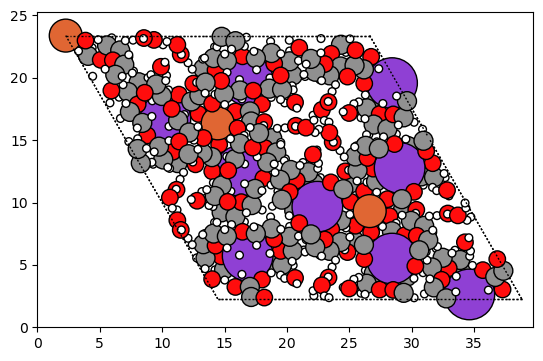

In [52]:
plot_atoms(atoms)

In [587]:
def find_row_indices(source, target):
    # List to store the indices of found rows
    found_indices = []
    found_rows = []
    remaining_indices = []
    remaining_rows = []
    # Iterate over each row in the source array with enumeration to track the index
    for index, row in enumerate(source):
        # Check if any row in the target array matches the current row
        if any(np.allclose(row, target_row) for target_row in target):
            found_indices.append(index)
            found_rows.append(row)
        else :
            remaining_indices.append(index)
            remaining_rows.append(row)
    # return remaining_indices, remaining_rows
    return found_indices, found_rows

In [147]:
157-3*3

148

In [150]:
(148 + 9*3)*3

525

In [152]:
cell_positions

array([[14.5861868 , 10.49193964,  6.84007412],
       [ 7.98962034,  7.38603849,  6.84007412],
       [13.97769286,  3.22619494,  6.84007412],
       ...,
       [-5.946036  , 20.86499244,  9.39382267],
       [-2.9120955 ,  5.52225862,  9.39382267],
       [ 8.8581315 , 15.82109507,  9.39382267]])

In [177]:
cell_positions

array([[14.5861868 , 10.49193964,  6.84007412],
       [ 7.98962034,  7.38603849,  6.84007412],
       [13.97769286,  3.22619494,  6.84007412],
       ...,
       [-5.946036  , 20.86499244,  9.39382267],
       [-2.9120955 ,  5.52225862,  9.39382267],
       [ 8.8581315 , 15.82109507,  9.39382267]])

In [489]:
from cell2mol.connectivity import compare_atoms, compare_species, compare_metals
debug = 2
unique_species = []
unique_indices = []

typelist_mols = [] # temporary variable  
typelist_ligs = [] # temporary variable
typelist_mets = [] # temporary variable

specs_found = -1
for idx, mol in enumerate(newcell.refmoleclist):
    if debug >= 2: print(f"Molecule {idx} formula={mol.formula}")
    found = False
    for ldx, typ in enumerate(typelist_mols):   # Molecules
        issame = compare_species(mol, typ[0], debug=0)
        if issame :
            found = True ; kdx = typ[1]
            if debug >= 2: print(f"Molecule {idx} is the same with {ldx} in typelist")
    if not found:
        specs_found += 1 ; kdx = specs_found
        typelist_mols.append(list([mol, kdx]))
        unique_species.append(mol)
        if debug >= 2: print(f"New molecule found with: formula={mol.formula} and added in position {kdx}")
    unique_indices.append(kdx)
    #     mol.unique_index = kdx

    # else:
    #     if not hasattr(mol,"ligands"): mol.split_complex(debug=debug)
    #     for jdx, lig in enumerate(mol.ligands):     # ligands
    #         found = False
    #         for ldx, typ in enumerate(typelist_ligs):
    #             issame = compare_species(lig, typ[0], debug=0)
    #             if issame :
    #                 found = True ; kdx = typ[1]
    #                 if debug >= 2: print(f"ligand {jdx} is the same with {ldx} in typelist")
    #         if not found:
    #             specs_found += 1 ; kdx = specs_found
    #             typelist_ligs.append(list([lig, kdx]))
    #             unique_species.append(lig)
    #             if debug >= 2: print(f"New ligand found with: formula {lig.formula} added in position {kdx}")
    #         unique_indices.append(kdx)
    #         lig.unique_index = kdx

    #     for jdx, met in enumerate(mol.metals):      #  metals
    #         found = False
    #         for ldx, typ in enumerate(typelist_mets):
    #             issame = compare_metals(met, typ[0], debug=0)
    #             if issame :
    #                 found = True ; kdx = typ[1]
    #                 if debug >= 2: print(f"Metal {jdx} is the same with {ldx} in typelist")
    #         if not found:
    #             specs_found += 1 ; kdx = specs_found
    #             typelist_mets.append(list([met, kdx]))
    #             unique_species.append(met)
    #             if debug >= 2: print(f"New Metal Center found with: labels {met.label} and added in position {kdx}")
    #         unique_indices.append(kdx)
    #         met.unique_index = kdx

Molecule 0 formula=C6-O12-Fe
New molecule found with: formula=C6-O12-Fe and added in position 0
Molecule 1 formula=H24-C12-O6
New molecule found with: formula=H24-C12-O6 and added in position 1
Molecule 2 formula=H2-O
New molecule found with: formula=H2-O and added in position 2
Molecule 3 formula=H2-O
Molecule 3 is the same with 2 in typelist
Molecule 4 formula=H2-O
Molecule 4 is the same with 2 in typelist
Molecule 5 formula=H24-C12-O6
Molecule 5 is the same with 1 in typelist
Molecule 6 formula=H24-C12-O6
Molecule 6 is the same with 1 in typelist
Molecule 7 formula=K
New molecule found with: formula=K and added in position 3
Molecule 8 formula=K
Molecule 8 is the same with 3 in typelist
Molecule 9 formula=K
Molecule 9 is the same with 3 in typelist


In [493]:
for specie in unique_species:
    print(specie.formula)

C6-O12-Fe
H24-C12-O6
H2-O
K


In [495]:
for ref, index in zip(newcell.refmoleclist, unique_indices):
    print(ref.formula, index)

C6-O12-Fe 0
H24-C12-O6 1
H2-O 2
H2-O 2
H2-O 2
H24-C12-O6 1
H24-C12-O6 1
K 3
K 3
K 3


In [492]:
unique_indices

[0, 1, 2, 2, 2, 1, 1, 3, 3, 3]

In [491]:
len(unique_indices)

10

In [ ]:
cell_positions

In [588]:
all_found = []

In [589]:
found_indices, found_rows = find_row_indices(cell_positions, new_structures[0].positions)

In [590]:
len(found_indices), len(found_rows)

(157, 157)

In [591]:
updated = [i for i in found_indices if i not in all_found]
for u in updated:
    print(u, cell_labels[u], cell_positions[u])

0 K [14.5861868  10.49193964  6.84007412]
1 K [7.98962034 7.38603849 6.84007412]
2 K [13.97769286  3.22619494  6.84007412]
9 Fe [12.18571845  7.03402088  9.3951224 ]
12 O [15.03530747  9.65114938  4.23131436]
13 O [8.49320573 8.19538353 4.23131436]
14 O [13.02498681  3.25764015  4.23131436]
21 O [12.4636469  10.43622462  4.93229304]
22 O [9.09914091 5.57572252 4.93229304]
23 O [14.9907122   5.09222592  4.93229304]
30 O [12.00940874 11.2968528   7.55450504]
31 O [8.58093412 4.75202665 7.55450504]
32 O [15.96315714  5.05529362  7.55450504]
39 O [14.17264487 12.40819855  9.00724948]
40 O [6.53686241 6.06977122 9.00724948]
41 O [15.84399273  2.6262033   9.00724948]
48 O [16.71213836 11.83121046  8.1503028 ]
49 O [5.76680201 8.55753114 8.1503028 ]
50 O [14.07455964  0.71543147  8.1503028 ]
57 O [17.23339127 10.87392517  5.5544104 ]
58 O [6.33520893 9.48759204 5.5544104 ]
59 O [12.9848998   0.74265585  5.5544104 ]
66 O [15.7326264   8.57842427  8.4251964 ]
67 O [9.07355346 9.335642   8.42519

In [566]:
updated_labels  = extract_from_list(updated, cell_labels, dimension=1)
updated_coord   = extract_from_list(updated, cell_positions, dimension=1)
updated_fracs = extract_from_list(updated, cell_fracs, dimension=1)

In [567]:
blocklist = split_species(updated_labels, updated_coord, debug=2)
print(blocklist)

SPILT_SPECIES: Laplacian lap=array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0, -1,  0],
       [ 0,  0,  0, ...,  0,  0, -1]])
SPILT_SPECIES: graph=<157x157 sparse matrix of type '<class 'numpy.int64'>'
	with 392 stored elements in Compressed Sparse Row format>
[[3, 22, 23, 24, 25, 26, 27, 145, 146, 147], [28, 31, 148], [29, 32, 149], [30, 33, 150], [111, 114, 117, 120, 123], [18, 102, 105], [34, 151], [36, 153, 156], [109, 112, 115, 118, 121], [35, 152, 155], [6, 9, 12, 15, 21, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 129, 132, 135, 138, 141, 144], [91, 94, 97], [92, 95, 98], [93, 96, 99], [16, 100, 103], [5, 8, 11, 14, 17, 20, 38, 41, 44, 47, 50, 53, 56, 59, 62, 65, 68, 71, 74, 77, 80, 83, 101, 104, 110, 113, 116, 119, 122, 125, 128, 131, 134, 137, 140, 143], [4, 7, 10, 13, 19, 37, 40, 43, 46, 49, 52, 55, 58, 61, 64, 67,

In [535]:
debug =2
fragments = []
for b in blocklist:
    print(updated)
    print(b)
    if debug > 0: print(f"CELL.MOLECLIST: doing block={b}")
    mol_labels  = extract_from_list(b, updated_labels, dimension=1)
    mol_coord   = extract_from_list(b, updated_coord, dimension=1)
    mol_indices = extract_from_list(b, updated, dimension=1)
    mol_frac_coord  = extract_from_list(b, updated_fracs, dimension=1)
    # Creates Molecule Object
    newmolec    = molecule(mol_labels, mol_coord)
    # For debugging
    newmolec.origin = "cell.get_moleclist"
    # Adds cell as parent of the molecule, with indices b
    newmolec.add_parent(newcell, indices=mol_indices)            
    newmolec.set_adjacency_parameters(cov_factor=1.3, metal_factor=1.0)
    # Creates The atom objects with adjacencies
    newmolec.set_atoms(create_adjacencies=True, debug=debug)
    newmolec.set_fractional_coord(mol_frac_coord, debug=debug)
    fragments.append(newmolec)

[0, 1, 2, 9, 12, 13, 14, 21, 22, 23, 30, 31, 32, 39, 40, 41, 48, 49, 50, 57, 58, 59, 66, 67, 68, 75, 76, 77, 84, 85, 86, 93, 94, 95, 102, 111, 120, 129, 130, 131, 138, 139, 140, 147, 148, 149, 156, 157, 158, 165, 166, 167, 174, 175, 176, 183, 184, 185, 192, 193, 194, 201, 202, 203, 210, 211, 212, 219, 220, 221, 228, 229, 230, 237, 238, 239, 246, 247, 248, 255, 256, 257, 264, 265, 266, 273, 274, 275, 282, 283, 284, 291, 292, 293, 300, 301, 302, 309, 310, 311, 318, 319, 320, 327, 328, 329, 336, 337, 338, 345, 346, 347, 354, 355, 356, 363, 364, 365, 372, 373, 374, 381, 382, 383, 390, 391, 392, 399, 400, 401, 408, 409, 410, 417, 418, 419, 426, 427, 428, 435, 436, 437, 444, 445, 446, 453, 454, 455, 462, 463, 464, 471, 480, 489, 498, 507, 516]
[3, 22, 23, 24, 25, 26, 27, 145, 146, 147]
CELL.MOLECLIST: doing block=[3, 22, 23, 24, 25, 26, 27, 145, 146, 147]
[0, 1, 2, 9, 12, 13, 14, 21, 22, 23, 30, 31, 32, 39, 40, 41, 48, 49, 50, 57, 58, 59, 66, 67, 68, 75, 76, 77, 84, 85, 86, 93, 94, 95, 102, 

In [536]:
fragments

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 10
  Formula                      = C3-O6-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = C-O2
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version   

In [538]:
from cell2mol.connectivity import compare_species
for frag in fragments:
    print(frag.formula, frag.get_parent_indices("cell"), frag.frac_coord)
    found = False
    for idx, ref in enumerate(newcell.refmoleclist):
        print(ref.formula, compare_species(frag, ref))

C3-O6-Fe [9, 66, 67, 68, 75, 76, 77, 453, 454, 455] [array([0.6667, 0.3333, 0.9638]), array([0.84884, 0.40648, 0.8643 ]), array([0.59352, 0.44236, 0.8643 ]), array([0.55764, 0.15116, 0.8643 ]), array([0.74737, 0.37844, 0.85468]), array([0.62156, 0.36893, 0.85468]), array([0.63107, 0.25263, 0.85468]), array([0.79509, 0.37857, 0.91   ]), array([0.62143, 0.41652, 0.91   ]), array([0.58348, 0.20491, 0.91   ])]
C6-O12-Fe False
H24-C12-O6 False
H2-O False
H2-O False
H2-O False
H24-C12-O6 False
H24-C12-O6 False
K False
K False
K False
C-O2 [84, 93, 462] [array([0.72235, 0.31431, 0.08222]), array([0.82236, 0.33812, 0.1071 ]), array([0.78019, 0.34031, 0.0458 ])]
C6-O12-Fe False
H24-C12-O6 False
H2-O False
H2-O False
H2-O False
H24-C12-O6 False
H24-C12-O6 False
K False
K False
K False
C-O2 [85, 94, 463] [array([0.68569, 0.40804, 0.08222]), array([0.66188, 0.48424, 0.1071 ]), array([0.65969, 0.43988, 0.0458 ])]
C6-O12-Fe False
H24-C12-O6 False
H2-O False
H2-O False
H2-O False
H24-C12-O6 False
H24

In [539]:
fragments

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 10
  Formula                      = C3-O6-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = C-O2
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version   

In [540]:
molecules = []
filtered_fragments = []
hydrogens = []
# found_list = []
for frag in fragments:
    print(frag.formula, frag.get_parent_indices("cell"))
    # print(frag.formula, frag.get_parent_indices("cell"), frag.frac_coord)
    found = False
    for idx, specie in enumerate(unique_species):
        issame = compare_species(frag, specie, debug=0)
        if issame :
            print(frag.formula, "matches with", specie.formula)
            found = True
            molecules.append(frag)
    if found == False:
        if frag.natoms == 1 and frag.labels == ["H"] :
            hydrogens.append(frag)
        else :
            filtered_fragments.append(frag)

C3-O6-Fe [9, 66, 67, 68, 75, 76, 77, 453, 454, 455]
C-O2 [84, 93, 462]
C-O2 [85, 94, 463]
C-O2 [86, 95, 464]
H3-C2 [347, 356, 365, 374, 383]
H-C-O [50, 320, 329]
H-O [102, 471]
H2-O [120, 489, 516]
H2-O matches with H2-O
H3-C2 [345, 354, 363, 372, 381]
H2-O [111, 480, 507]
H2-O matches with H2-O
H14-C8-O5 [14, 23, 32, 41, 59, 131, 140, 149, 158, 167, 176, 185, 194, 203, 212, 221, 230, 239, 248, 257, 266, 401, 410, 419, 428, 437, 446]
H2-C [291, 300, 309]
H2-C [292, 301, 310]
H2-C [293, 302, 311]
H-C-O [48, 318, 327]
H19-C11-O6 [13, 22, 31, 40, 49, 58, 130, 139, 148, 157, 166, 175, 184, 193, 202, 211, 220, 229, 238, 247, 256, 265, 319, 328, 346, 355, 364, 373, 382, 391, 400, 409, 418, 427, 436, 445]
H14-C8-O5 [12, 21, 30, 39, 57, 129, 138, 147, 156, 165, 174, 183, 192, 201, 210, 219, 228, 237, 246, 255, 264, 399, 408, 417, 426, 435, 444]
H [336]
H [498]
K [1]
K matches with K
K [2]
K matches with K
H [274]
H [273]
H [337]
H [275]
H [282]
H [392]
H [283]
H [390]
H [284]
H [338]
K [0]
K m

In [541]:
def custom_sort_key(item):
    index, (x, chemical) = item
    return (x, -1 if "H-O" in chemical else 1, index)  # Adjusted for "H-O" as requested

data = [(frag.natoms, frag.formula) for frag in filtered_fragments]
# Enumerate the list and sort
sorted_data = sorted(enumerate(data), key=custom_sort_key)
original_indices = [original_index for original_index, (x, chemical) in sorted_data]
sorted_filtered_fragments = [(x, chemical) for original_index, (x, chemical) in sorted_data]
print(original_indices)
print(sorted_filtered_fragments)
sorted_fragments = [filtered_fragments[i] for i in original_indices]

[6, 1, 2, 3, 5, 9, 10, 11, 12, 4, 7, 0, 8, 14, 13]
[(2, 'H-O'), (3, 'C-O2'), (3, 'C-O2'), (3, 'C-O2'), (3, 'H-C-O'), (3, 'H2-C'), (3, 'H2-C'), (3, 'H2-C'), (3, 'H-C-O'), (5, 'H3-C2'), (5, 'H3-C2'), (10, 'C3-O6-Fe'), (27, 'H14-C8-O5'), (27, 'H14-C8-O5'), (36, 'H19-C11-O6')]


In [542]:
molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version        

In [543]:
all_fragments = sorted_fragments+hydrogens

In [544]:
## Prepares Blocks
for b in all_fragments:
    if debug >= 2: print(f"CLASSIFY_FRAGMENTS, preparing block\n{b.formula}")
    if not hasattr(b,"centroid"):         b.get_centroid()
    if not hasattr(b,"element_count"):    b.set_element_count()
    if not hasattr(b,"numH"):             b.numH = b.set_element_count()[4] + b.set_element_count()[3] #"Hidrogen + Deuterium atoms"
## Prepares Reference Molecules
for ref in unique_species:
    if debug >= 2: print(f"CLASSIFY_FRAGMENTS, preparing reference\n{ref.formula}")
    if not hasattr(ref,"element_count"):  ref.set_element_count()
    if not hasattr(ref,"numH"):           ref.numH = ref.set_element_count()[4] + ref.set_element_count()[3] #"Hidrogen + Deuterium atoms"


CLASSIFY_FRAGMENTS, preparing block
H-O
CLASSIFY_FRAGMENTS, preparing block
C-O2
CLASSIFY_FRAGMENTS, preparing block
C-O2
CLASSIFY_FRAGMENTS, preparing block
C-O2
CLASSIFY_FRAGMENTS, preparing block
H-C-O
CLASSIFY_FRAGMENTS, preparing block
H2-C
CLASSIFY_FRAGMENTS, preparing block
H2-C
CLASSIFY_FRAGMENTS, preparing block
H2-C
CLASSIFY_FRAGMENTS, preparing block
H-C-O
CLASSIFY_FRAGMENTS, preparing block
H3-C2
CLASSIFY_FRAGMENTS, preparing block
H3-C2
CLASSIFY_FRAGMENTS, preparing block
C3-O6-Fe
CLASSIFY_FRAGMENTS, preparing block
H14-C8-O5
CLASSIFY_FRAGMENTS, preparing block
H14-C8-O5
CLASSIFY_FRAGMENTS, preparing block
H19-C11-O6
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, 

In [524]:
from cell2mol.hungarian import reorder

In [547]:
finalmols

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------]

In [556]:
all_fragments

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Heavy
  Number of Atoms              = 2
  Formula                      = H-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Heavy
  Number of Atoms              = 3
  Formula                      = C-O2
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version               

In [561]:
finalmols, final_remfrag = sequential(all_fragments, unique_species, cellvec=newcell.cellvec, typ="All", debug=2)

Entered sequential with 27 fragments to reconstruct
Found 15 and 12 Heavy and Hydrogen fragments, respectively
 
Fragments to allocate: 0 0 out of 14 11
sublist 2 ['H-O', 'H']
list1 15 ['H-O', 'C-O2', 'C-O2', 'C-O2', 'H-C-O', 'H2-C', 'H2-C', 'H2-C', 'H-C-O', 'H3-C2', 'H3-C2', 'C3-O6-Fe', 'H14-C8-O5', 'H14-C8-O5', 'H19-C11-O6']
list2 12 ['H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
keeplist1 14 ['C-O2', 'C-O2', 'C-O2', 'H-C-O', 'H2-C', 'H2-C', 'H2-C', 'H-C-O', 'H3-C2', 'H3-C2', 'C3-O6-Fe', 'H14-C8-O5', 'H14-C8-O5', 'H19-C11-O6']
keeplist2 11 ['H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']

SEQUENTIAL All iteration 1 with 15 and 12 Remaining in each list
SEQUENTIAL All sending ['O', 'H'] and ['H'] to combine
MERGE_FRAGMENTS: keep_idx 0
MERGE_FRAGMENTS: move_idx 1
MERGE_FRAGMENTS: move_frag.tmatrix [(0, 0, 0), (1, 0, 0), (0, 0, 1), (1, 0, 1)]
MERGE_FRAGMENTS: translation (0, 0, 0)
MERGE_FRAGMENTS: count_species found 2
MERGE_FRAGMENTS: translation (1, 0, 0)
MERGE_FR

In [528]:
finalmols

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------]

In [502]:
molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------]

In [471]:
molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version        

In [458]:
hydrogens

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = H
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = H
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version              

In [459]:
all_found.extend(found_indices)

In [460]:
len(set(all_found))

157

In [461]:
len(set(all_found)) == len(cell_positions) # then stop

False

In [184]:
len(found_indices), len(found_rows)

(157, 157)

In [185]:
found_indices

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156]

In [156]:
remaining_indices, remaining_rows

([], [])

In [139]:
for i in remaining_indices:
    print(ref_labels[i], new_structures[6].positions[i], new_structures[7].positions[i])

Fe [-12.18328155  21.10346959   6.14578907] [3.76537886e-16 1.40694487e-03 6.14578907e+00]
O [6.19996098 1.67327954 6.21499987] [19.81991693  4.53268394  6.21499987]
O [-3.23693427  6.29678177  1.30005827] [ 8.34979416 15.15251487  1.30005827]
O [-5.91837718 20.90867807  8.50772947] [-2.96375778  5.52436904  8.50772947]
H [5.3709276  1.63909077 5.96252667] [20.26404195  3.83181436  5.96252667]
H [-3.2630091   7.12617577  0.99104667] [ 7.6445553  14.71523641  0.99104667]
H [-6.7892034  20.7383674   8.39952667] [-2.3808513   4.85536675  8.39952667]
H [6.35421675 1.21911773 6.92757867] [20.1361047   4.89335426  6.92757867]
H [20.29815855  6.55425268  1.42970667] [ 8.5437714  14.30159461  1.42970667]
H [-5.946036   20.86499244  9.39382267] [-2.9120955   5.52225862  9.39382267]


In [71]:
for l, i, j in zip(ref_labels, new_structures[0].positions, new_structures[1].positions):
    print(l, i, j, np.allclose(i, j, rtol=1e-03, atol=1e-05))

K [14.5861868  10.49193964  6.84007412] [7.98962034 7.38603849 6.84007412] False
Fe [12.18571845  7.03402088  9.3951224 ] [12.1845     7.0361313  9.3951224] True
O [15.03530746  9.65114938  4.23131436] [8.49320573 8.19538353 4.23131436] False
O [12.4636469  10.43622462  4.93229304] [9.09914091 5.57572252 4.93229304] False
O [12.00940874 11.2968528   7.55450504] [8.58093412 4.75202665 7.55450504] False
O [14.17264487 12.40819855  9.00724948] [6.53686241 6.06977122 9.00724948] False
O [16.71213836 11.83121046  8.1503028 ] [5.76680201 8.55753114 8.1503028 ] False
O [17.23339127 10.87392517  5.5544104 ] [6.33520893 9.48759204 5.5544104 ] False
O [15.7326264   8.57842427  8.4251964 ] [9.07355346 9.335642   8.4251964 ] False
O [13.60155735  7.98666325  8.33142064] [10.65156806  7.78596257  8.33142064] False
O [13.77323696  6.63325264  0.80148056] [11.73781623  8.61134678  0.80148056] False
O [15.9202677  7.135743   1.0440108] [10.22913144 10.21948476  1.0440108 ] False
O [18.38446098  8.7080

In [ ]:
combined_mol = new_structures_2[0]
combined_mol.set_cell(atoms.get_cell())
combined_mol.set_pbc(True)
plot_atoms(combined_mol)
view = nglview.show_ase(combined_mol)
view.add_unitcell()
view

<AxesSubplot: >

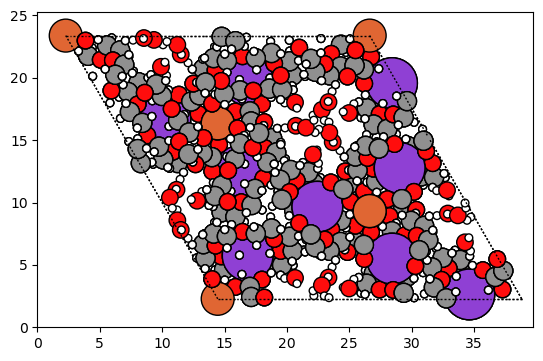

In [55]:
combined_mol = new_structures[0] + new_structures[1] + new_structures[2] + new_structures[3] + new_structures[4] + new_structures[5] + new_structures[6] + new_structures[7] + new_structures[8]
combined_mol.set_cell(atoms.get_cell())
combined_mol.set_pbc(True)
plot_atoms(combined_mol)

NGLWidget()

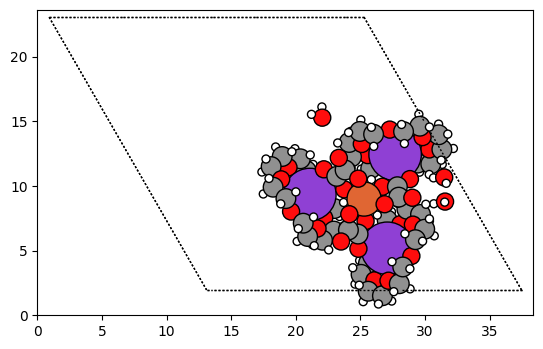

In [253]:
combined_mol = new_structures_2[0]
combined_mol.set_cell(atoms.get_cell())
combined_mol.set_pbc(True)
plot_atoms(combined_mol)
view = nglview.show_ase(combined_mol)
view.add_unitcell()
view

In [249]:
new_structures_2 = apply_symmetry_operations_to_frac(ref_molecuele, cell_parameters, ref_fracs, sym_ops, normalize=False)


<Axes: >

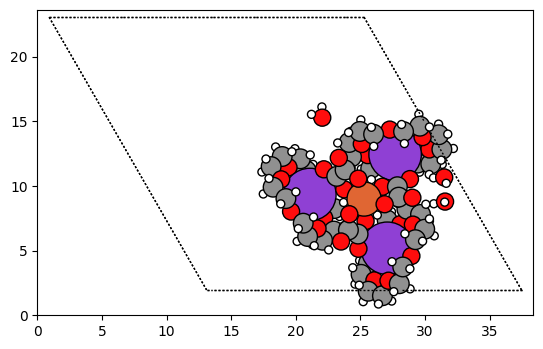

In [251]:
combined_mol = new_structures_2[0] 
combined_mol.set_cell(atoms.get_cell())
combined_mol.set_pbc(True)
plot_atoms(combined_mol)

In [266]:
cellvec

[[14.0694487, 0.0, 3.2493333],
 [-7.0347244, 12.1845, 3.2493333],
 [-7.0347244, -12.1845, 3.2493333]]

In [270]:
i =0 
frac_1 = cart2frac(new_structures[i].positions, cellvec)
frac_2 = cart2frac(new_structures_2[i].positions, cellvec)

for l, f, nm, un, f1, f2 in zip(ref_labels, ref_fracs, new_structures[i].positions, new_structures_2[i].positions, frac_1, frac_2):
    if not np.allclose(np.array(nm), np.array(un)):
        print(l, f)
        print(f1, f2)
        print(nm, un)
        print("===")

O [0.72235, 0.31431, 1.08222]
[0.7348509709344841, 0.028104960461427367, -0.5162959288655464] [1.7348509859313979, 1.0281049683507424, 0.48370407902376855]
[13.77323696  6.63325264  0.80148056] [13.77323696  6.63325264 10.54948056]
===
O [0.82236, 0.33812, 1.1071]
[0.8614658620719366, 0.02273758013965642, -0.5629034389155325] [1.861465877068851, 1.0227375880289715, 0.43709656897378246]
[15.9202677  7.135743   1.0440108] [15.9202677  7.135743  10.7920108]
===
H [0.8213, 0.5964, 1.0632]
[0.6672238515671878, 0.2776856260059526, -0.7553094756281261] [1.667223866564102, 1.2776856338952676, 0.2446905322611889]
[12.7474239  12.58652882  0.6160736 ] [12.7474239  12.58652882 10.3640736 ]
===
H [0.7941, 0.5267, 1.0099]
[0.6227573098717297, 0.15960692538973786, -0.7526642349567898] [1.6227573248686438, 1.159606933279053, 0.2473357729325252]
[12.93384675 11.11556795  0.0965052 ] [12.93384675 11.11556795  9.8445052 ]
===
C [0.91569, 0.58064, 1.0182]
[0.740315074755535, 0.15999145335568643, -0.84570

In [306]:
from cell2mol.connectivity import split_species
from cell2mol.other import extract_from_list
from cell2mol.classes import molecule, cell

In [33]:
blocklist = split_species(ref_labels, ref_pos, debug=debug)
print(len(blocklist))

SPILT_SPECIES: Laplacian lap=array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0, -6,  0, ...,  0,  0,  0],
       [ 0,  0, -2, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., -3,  0,  1],
       [ 0,  0,  0, ...,  0, -3,  0],
       [ 0,  0,  0, ...,  1,  0, -3]])
SPILT_SPECIES: graph=<157x157 sparse matrix of type '<class 'numpy.int64'>'
	with 460 stored elements in Compressed Sparse Row format>
10


In [35]:
mol = new_structures[0]
debug = 2
print(len(mol.get_chemical_symbols()))
blocklist = split_species(mol.get_chemical_symbols(), mol.positions, debug=debug)
print(len(blocklist))

157
SPILT_SPECIES: Laplacian lap=array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0, -3,  0, ...,  0,  0,  0],
       [ 0,  0, -2, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., -2,  0,  0],
       [ 0,  0,  0, ...,  0, -2,  0],
       [ 0,  0,  0, ...,  0,  0, -2]])
SPILT_SPECIES: graph=<157x157 sparse matrix of type '<class 'numpy.int64'>'
	with 392 stored elements in Compressed Sparse Row format>
32


In [25]:
name = "BOFFOS"
refcell = cell(name, ref_labels, ref_pos, cellvec, cellparam)

In [26]:
refcell

------------- Cell2mol CELL Object ----------------
 Version               = 0.1
 Type                  = cell
 Name (Refcode)        = BOFFOS
 Num Atoms             = 157
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
---------------------------------------------------

In [93]:
fragments = []
for b in blocklist:
    if debug > 0: print(f"CELL.MOLECLIST: doing block={b}")
    mol_labels  = extract_from_list(b, ref_labels, dimension=1)
    mol_coord   = extract_from_list(b, ref_pos, dimension=1)
    # Creates Molecule Object
    newmolec    = molecule(mol_labels, mol_coord)
    # For debugging
    newmolec.origin = "cell.get_moleclist"
    # Adds cell as parent of the molecule, with indices b
    newmolec.add_parent(refcell, indices=b)            
    newmolec.set_adjacency_parameters(cov_factor=1.3, metal_factor=1.0)
    # Creates The atom objects with adjacencies
    newmolec.set_atoms(create_adjacencies=True, debug=debug)
    mol_frac_coord  = extract_from_list(b, ref_fracs, dimension=1)
    newmolec.set_fractional_coord(mol_frac_coord, debug=debug)
    fragments.append(newmolec)

CELL.MOLECLIST: doing block=[14, 55, 58]
CELL.MOLECLIST: doing block=[13, 54, 57]
CELL.MOLECLIST: doing block=[33, 34, 35]
CELL.MOLECLIST: doing block=[10, 11, 52]
CELL.MOLECLIST: doing block=[12, 53]
CELL.MOLECLIST: doing block=[6, 36, 37]
CELL.MOLECLIST: doing block=[39, 40, 41, 42, 43]
CELL.MOLECLIST: doing block=[2, 3, 4, 5, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 45, 46, 47, 48, 49, 50]
CELL.MOLECLIST: doing block=[117, 119, 121]
CELL.MOLECLIST: doing block=[118, 120, 122]
CELL.MOLECLIST: doing block=[130, 132, 134, 136, 137]
CELL.MOLECLIST: doing block=[70, 124, 126]
CELL.MOLECLIST: doing block=[1, 8, 9, 51, 73, 74, 75, 76, 153, 154]
CELL.MOLECLIST: doing block=[78, 79, 156]
CELL.MOLECLIST: doing block=[77, 80, 155]
CELL.MOLECLIST: doing block=[62, 64, 66, 68, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 141, 143, 145, 147, 149, 151]
CELL.MOLECLIST: doing block=[61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99

In [95]:
temp = []
for b in blocklist:
    temp.extend(b)
print(sorted(set(temp)))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156]


H ['H'] [[18.148812750000005, 10.04347596154926, 7.108241599999998]]


NGLWidget()

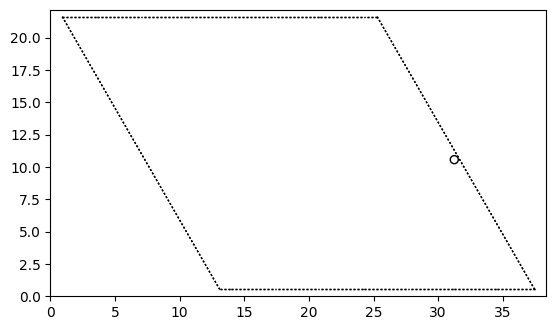

In [91]:
frag = fragments[27]
print(frag.formula, frag.labels, frag.coord)
frag_mol = Atoms(symbols=frag.labels, positions=frag.coord, cell=cell_parameters, pbc=True)
plot_atoms(frag_mol)
view = nglview.show_ase(frag_mol)
view.add_unitcell()
view

In [71]:
from cell2mol.cell_reconstruction import classify_fragments, fragments_reconstruct

In [411]:
def classify_fragments_v2 (blocklist: list, refmoleclist: list, debug: int=0):
    init_natoms = 0
    moleclist = []
    fraglist  = []
    Hlist     = []

    ## Prepares Blocks
    for b in blocklist:
        if debug >= 2: print(f"CLASSIFY_FRAGMENTS, preparing block\n{b.formula}")
        if not hasattr(b,"centroid"):         b.get_centroid()
        if not hasattr(b,"element_count"):    b.set_element_count()
        if not hasattr(b,"numH"):             b.numH = b.set_element_count()[4] + b.set_element_count()[3] #"Hidrogen + Deuterium atoms"
    ## Prepares Reference Molecules
    for ref in refmoleclist:
        if debug >= 2: print(f"CLASSIFY_FRAGMENTS, preparing reference\n{ref.formula}")
        if not hasattr(ref,"element_count"):  ref.set_element_count()
        if not hasattr(ref,"numH"):           ref.numH = ref.set_element_count()[4] + ref.set_element_count()[3] #"Hidrogen + Deuterium atoms"

    # Classifies blocks and puts them in 3 bags. (1) Full molecules, (2) partial molecules=fragments, (3) Hydrogens
    for idx, block in enumerate(blocklist):
        if (block.natoms == 1) and (block.numH == 1):
            block.subtype = "H"
            Hlist.append(block)
        else:
            found = False 
            for ref in refmoleclist:
                issame = compare_species(ref, block, debug=2)
                if issame: 
                    block.subtype = "molecule"
                    moleclist.append(block)
                    found = True
            if not found:
                block.subtype = "fragment"
                fraglist.append(block)

    if debug > 0: print(f"CLASSIFY_FRAGMENTS. {len(blocklist)} Blocks sorted as (Molec, Frag, H): {len(moleclist)} {len(fraglist)} {len(Hlist)}")
    return moleclist, fraglist, Hlist

In [88]:
def compare_species(mol1, mol2, check_coordinates: bool=False, debug: int=0):
    from cell2mol.elementdata import ElementData
    elemdatabase = ElementData()
    elems = elemdatabase.elementnr.keys()

    if debug > 0: 
        print("COMPARE_SPECIES. Comparing:")
        print(mol1.formula)
        print(mol2.formula)

    
    # a pair of species is compared on the basis of:
    # 1) the total number of atoms
    if (mol1.natoms != mol2.natoms): 
        if debug > 0: print("COMPARE_SPECIES. FALSE, different natoms:")
        return False

    # 2) the total number of electrons (as sum of atomic number)
    if (mol1.eleccount != mol2.eleccount): 
        if debug > 0: print("COMPARE_SPECIES. FALSE, different eleccount:")
        return False

    # 3) the number of atoms of each type
    if not hasattr(mol1,"element_count"): mol1.set_element_count()
    if not hasattr(mol2,"element_count"): mol2.set_element_count()
    for kdx, elem in enumerate(mol1.element_count):
        if elem != mol2.element_count[kdx]: 
            if debug > 0: print(f"COMPARE_SPECIES. FALSE, different {elem} count:")
            return False       
    # writexyz(os.getcwd(), f"reordered.xyz", mol1.labels, mol1.coord)
    # 4) the number of adjacencies between each pair of element types
    if not hasattr(mol1,"adj_types"):     mol1.set_adj_types()
    if not hasattr(mol2,"adj_types"):     mol2.set_adj_types()
    if debug == 2: print(f"{mol1.adj_types=}")
    if debug == 2: print(f"{mol2.adj_types=}")

    count = 0
    if debug > 0: print("COMPARE_SPECIES. kdx ldx elem1 - elem2 : reordered - reference")
    for kdx, (elem, row1) in enumerate(zip(elems, mol1.adj_types)):
        for ldx, (elem2, val1) in enumerate(zip(elems, row1)):
            val2 = mol2.adj_types[kdx, ldx]
            if val1 != val2: 
                count += 1
                if debug > 0: print(f"COMPARE_SPECIES. FALSE, different adjacency count")
                if debug > 0: print(f"COMPARE_SPECIES. {kdx} {ldx} {elem} - {elem2} : {val1} - {val2}")
                
    if count > 0 : return False
    else: return True

In [97]:
molecules, fragments_new, hydrogens = classify_fragments_v2(fragments, newcell.refmoleclist, debug=debug)

CLASSIFY_FRAGMENTS, preparing block
H2-O
CLASSIFY_FRAGMENTS, preparing block
H2-O
CLASSIFY_FRAGMENTS, preparing block
H2-C
CLASSIFY_FRAGMENTS, preparing block
C-O2
CLASSIFY_FRAGMENTS, preparing block
H-O
CLASSIFY_FRAGMENTS, preparing block
H-C-O
CLASSIFY_FRAGMENTS, preparing block
H3-C2
CLASSIFY_FRAGMENTS, preparing block
H14-C8-O5
CLASSIFY_FRAGMENTS, preparing block
H2-C
CLASSIFY_FRAGMENTS, preparing block
H2-C
CLASSIFY_FRAGMENTS, preparing block
H3-C2
CLASSIFY_FRAGMENTS, preparing block
H-C-O
CLASSIFY_FRAGMENTS, preparing block
C3-O6-Fe
CLASSIFY_FRAGMENTS, preparing block
C-O2
CLASSIFY_FRAGMENTS, preparing block
C-O2
CLASSIFY_FRAGMENTS, preparing block
H14-C8-O5
CLASSIFY_FRAGMENTS, preparing block
H19-C11-O6
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGMENTS, preparing block
H
CLASSIFY_FRAGM

In [100]:
len(blocklist), len(fragments)

(32, 32)

In [116]:
for ref in newcell.refmoleclist:
    ref_labels_idx = [ref_labels[i] for i in ref.get_parent_indices("cell")]
    ref_frac_idx = [ref_fracs[i] for i in ref.get_parent_indices("cell")]
    print(ref.formula, ref.get_parent_indices("cell"), ref_frac_idx)

C6-O12-Fe [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156] [[0.6667, 0.3333, 0.9638], [0.84884, 0.40648, 0.8643], [0.74737, 0.37844, 0.85468], [0.72235, 0.31431, 1.08222], [0.82236, 0.33812, 1.1071], [0.79509, 0.37857, 0.91], [0.78019, 0.34031, 1.0458], [0.59352, 0.44236, 0.8643], [0.55764, 0.15116, 0.8643], [0.62156, 0.36893, 0.85468], [0.63107, 0.25263, 0.85468], [0.68569, 0.40804, 1.08222], [0.59196, 0.27765, 1.08222], [0.51576, 0.17764, 1.1071], [0.66188, 0.48424, 1.1071], [0.62143, 0.41652, 0.91], [0.58348, 0.20491, 0.91], [0.65969, 0.43988, 1.0458], [0.56012, 0.21981, 1.0458]]
H24-C12-O6 [2, 3, 4, 5, 6, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50] [[0.84564, 0.45731, 0.43407], [0.75871, 0.49451, 0.50598], [0.76046, 0.53529, 0.77498], [0.87556, 0.58795, 0.92401], [0.9661, 0.56061, 0.8361], [0.96481, 0.51525, 0.5698], [0.80239, 0.45809, 0.338], [0.7927,

In [304]:
molecules = []
filtered_fragments = []
hydrogens = []
found_list = []
for frag in fragments:
    # print(frag.formula, frag.get_parent_indices("cell"), frag.frac_coord)
    found = False
    for idx, ref in enumerate(newcell.refmoleclist):
        if (ref.natoms == frag.natoms) & (ref.formula == frag.formula) & (sorted(ref.get_parent_indices("cell")) == sorted(frag.get_parent_indices("cell"))):
            print(frag.formula, frag.get_parent_indices("cell"), frag.frac_coord, f"equivalent to Ref {idx} {ref.formula}")
            molecules.append(frag)
            found = True
            found_list.append(idx)
    if found == False:
        if frag.natoms == 1 and frag.labels == ["H"] :
            hydrogens.append(frag)
        else :
            filtered_fragments.append(frag)

H2-O [14, 55, 58] [[0.91917, 0.32407, 0.2061], [0.8794, 0.316, 0.195], [0.917, 0.322, 0.297]] equivalent to Ref 4 H2-O
H2-O [13, 54, 57] [[0.68302, 0.6317, 0.4667], [0.7016, 0.671, 0.435], [0.6549, 0.6439, 0.48]] equivalent to Ref 3 H2-O
K [59] [[0.50285, 0.34998, 0.70169]] equivalent to Ref 7 K
K [60] [[0.65002, 0.15287, 0.70169]] equivalent to Ref 8 K
K [0] [[0.84713, 0.49715, 0.70169]] equivalent to Ref 9 K


In [305]:
found_list

[4, 3, 7, 8, 9]

In [313]:
np.arange(len(newcell.refmoleclist))

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [317]:
filtered_list = [item for item in list(np.arange(len(newcell.refmoleclist))) if item not in found_list]
for i in filtered_list:
    print

[0, 1, 2, 5, 6]

In [137]:
len(molecules)

5

In [136]:
len(hydrogens)

12

In [135]:
len(filtered_fragments)

15

In [207]:
# Custom sorting key
def custom_sort_key(item):
    x, chemical = item
    return (x, -1 if "O-H" in chemical else 1)
data = [(frag.natoms, frag.formula) for frag in filtered_fragments]
# Sorting the list
sorted_data = sorted(data, key=custom_sort_key)

print(sorted_data)

[(2, 'H-O'), (3, 'H2-C'), (3, 'C-O2'), (3, 'H-C-O'), (3, 'H2-C'), (3, 'H2-C'), (3, 'H-C-O'), (3, 'C-O2'), (3, 'C-O2'), (5, 'H3-C2'), (5, 'H3-C2'), (10, 'C3-O6-Fe'), (27, 'H14-C8-O5'), (27, 'H14-C8-O5'), (36, 'H19-C11-O6')]


In [306]:
def custom_sort_key(item):
    index, (x, chemical) = item
    return (x, -1 if "H-O" in chemical else 1, index)  # Adjusted for "H-O" as requested

print(data)
data = [(frag.natoms, frag.formula) for frag in filtered_fragments]
# Enumerate the list and sort
sorted_data = sorted(enumerate(data), key=custom_sort_key)
original_indices = [original_index for original_index, (x, chemical) in sorted_data]
sorted_filtered_fragments = [(x, chemical) for original_index, (x, chemical) in sorted_data]
print(original_indices)
print(sorted_filtered_fragments)
sorted_fragments = [filtered_fragments[i] for i in original_indices]


[(3, 'H2-C'), (3, 'C-O2'), (2, 'H-O'), (3, 'H-C-O'), (5, 'H3-C2'), (27, 'H14-C8-O5'), (3, 'H2-C'), (3, 'H2-C'), (5, 'H3-C2'), (3, 'H-C-O'), (10, 'C3-O6-Fe'), (3, 'C-O2'), (3, 'C-O2'), (27, 'H14-C8-O5'), (36, 'H19-C11-O6')]
[2, 0, 1, 3, 6, 7, 9, 11, 12, 4, 8, 10, 5, 13, 14]
[(2, 'H-O'), (3, 'H2-C'), (3, 'C-O2'), (3, 'H-C-O'), (3, 'H2-C'), (3, 'H2-C'), (3, 'H-C-O'), (3, 'C-O2'), (3, 'C-O2'), (5, 'H3-C2'), (5, 'H3-C2'), (10, 'C3-O6-Fe'), (27, 'H14-C8-O5'), (27, 'H14-C8-O5'), (36, 'H19-C11-O6')]


In [307]:
sorted_fragments = [filtered_fragments[i] for i in original_indices]


In [308]:
sorted_fragments

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Heavy
  Number of Atoms              = 2
  Formula                      = H-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Heavy
  Number of Atoms              = 3
  Formula                      = H2-C
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version               

In [309]:
[(frag.natoms, frag.formula) for frag in filtered_fragments]

[(3, 'H2-C'),
 (3, 'C-O2'),
 (2, 'H-O'),
 (3, 'H-C-O'),
 (5, 'H3-C2'),
 (27, 'H14-C8-O5'),
 (3, 'H2-C'),
 (3, 'H2-C'),
 (5, 'H3-C2'),
 (3, 'H-C-O'),
 (10, 'C3-O6-Fe'),
 (3, 'C-O2'),
 (3, 'C-O2'),
 (27, 'H14-C8-O5'),
 (36, 'H19-C11-O6')]

In [140]:
for i, remo in enumerate(filtered_fragments):
    print(i, remo.formula)

0 H2-C
1 C-O2
2 H-O
3 H-C-O
4 H3-C2
5 H14-C8-O5
6 H2-C
7 H2-C
8 H3-C2
9 H-C-O
10 C3-O6-Fe
11 C-O2
12 C-O2
13 H14-C8-O5
14 H19-C11-O6


In [512]:
def tmatgenerator(centroid, thres=0.40, full=False, debug: int=0):
    # This function generates a list of the translations that a fragment should undergo depending on the centroid of its fractional coordinates
    # For instance, if the centroid of a fragment is at 0.9 in any given axis, it is unlikely that a one-cell-length translation along such axis (resulting in 1.9) would help.
    # Also, a fragment right at the center of the unit cell (centroid=(0.5, 0.5, 0.5) is unlikely to require reconstruction
    # The threshold defines the window. If thres=0.4, the function will suggest positive translation for any fragment between 0 and 0.4, and negative translation between 0.6 and 1.0.
    # If full is asked, then all translations are applied

    tmax = 1 - thres
    tmin = thres

    if not full:
        tmatrix = []
        tmatrix = additem((0, 0, 0), tmatrix)

        # X positive
        if centroid[0] >= tmax:
            tmatrix = additem((-1, 0, 0), tmatrix)
            if centroid[1] >= tmax:
                tmatrix = additem((-1, -1, 0), tmatrix)
                tmatrix = additem((0, -1, 0), tmatrix)
                if centroid[2] >= tmax:
                    tmatrix = additem((-1, -1, -1), tmatrix)
                    tmatrix = additem((0, -1, -1), tmatrix)
                    tmatrix = additem((0, 0, -1), tmatrix)
                if centroid[2] <= tmin:
                    tmatrix = additem((-1, -1, 1), tmatrix)
                    tmatrix = additem((0, -1, 1), tmatrix)
                    tmatrix = additem((0, 0, 1), tmatrix)
            if centroid[1] <= tmin:
                tmatrix = additem((-1, 1, 0), tmatrix)
                tmatrix = additem((0, 1, 0), tmatrix)
                if centroid[2] >= tmax:
                    tmatrix = additem((-1, 1, -1), tmatrix)
                    tmatrix = additem((0, 1, -1), tmatrix)
                    tmatrix = additem((0, 0, -1), tmatrix)
                if centroid[2] <= tmin:
                    tmatrix = additem((-1, 1, 1), tmatrix)
                    tmatrix = additem((0, 1, 1), tmatrix)
                    tmatrix = additem((0, 0, 1), tmatrix)
            if centroid[2] >= tmax:
                tmatrix = additem((-1, 0, -1), tmatrix)
                tmatrix = additem((0, 0, -1), tmatrix)
            if centroid[2] <= tmin:
                tmatrix = additem((-1, 0, 1), tmatrix)
                tmatrix = additem((0, 0, 1), tmatrix)

        if centroid[1] >= tmax:
            tmatrix = additem((0, -1, 0), tmatrix)
            if centroid[2] >= tmax:
                tmatrix = additem((0, -1, -1), tmatrix)
                tmatrix = additem((0, 0, -1), tmatrix)
            if centroid[2] <= tmin:
                tmatrix = additem((0, -1, 1), tmatrix)
                tmatrix = additem((0, 0, 1), tmatrix)

        if centroid[2] >= tmax:
            tmatrix = additem((0, 0, -1), tmatrix)

        if centroid[0] <= tmin:
            tmatrix = additem((1, 0, 0), tmatrix)
            if centroid[1] <= tmin:
                tmatrix = additem((1, 1, 0), tmatrix)
                tmatrix = additem((0, 1, 0), tmatrix)
                if centroid[2] <= tmin:
                    tmatrix = additem((1, 1, 1), tmatrix)
                    tmatrix = additem((0, 1, 1), tmatrix)
                    tmatrix = additem((0, 0, 1), tmatrix)
                if centroid[2] >= tmax:
                    tmatrix = additem((1, 1, -1), tmatrix)
                    tmatrix = additem((0, 1, -1), tmatrix)
                    tmatrix = additem((0, 0, -1), tmatrix)
            if centroid[1] >= tmax:
                tmatrix = additem((1, -1, 0), tmatrix)
                tmatrix = additem((0, -1, 0), tmatrix)
                if centroid[2] >= tmax:
                    tmatrix = additem((1, -1, -1), tmatrix)
                if centroid[2] <= tmin:
                    tmatrix = additem((1, -1, 1), tmatrix)
            if centroid[2] <= tmin:
                tmatrix = additem((1, 0, 1), tmatrix)
                tmatrix = additem((0, 0, 1), tmatrix)
            if centroid[2] >= tmax:
                tmatrix = additem((1, 0, -1), tmatrix)
                tmatrix = additem((0, 0, -1), tmatrix)

        if centroid[1] <= tmin:
            tmatrix = additem((0, 1, 0), tmatrix)
            if centroid[2] <= tmin:
                tmatrix = additem((0, 1, 1), tmatrix)
                tmatrix = additem((0, 0, 1), tmatrix)
            if centroid[2] >= tmax:
                tmatrix = additem((0, 1, -1), tmatrix)
                tmatrix = additem((0, 0, -1), tmatrix)
        if centroid[2] <= tmin:
            tmatrix = additem((0, 0, 1), tmatrix)

        if (centroid[0] > tmin) and (centroid[0] < tmax):
            if centroid[1] <= tmin:
                tmatrix = additem((0, 1, 0), tmatrix)
                if centroid[2] >= tmax:
                    tmatrix = additem((0, 1, -1), tmatrix)
                if centroid[2] <= tmin:
                    tmatrix = additem((0, 1, 1), tmatrix)
            if centroid[1] >= tmax:
                tmatrix = additem((0, -1, 0), tmatrix)
                if centroid[2] >= tmax:
                    tmatrix = additem((0, -1, -1), tmatrix)
                if centroid[2] <= tmin:
                    tmatrix = additem((0, -1, 1), tmatrix)
            if centroid[2] <= tmin:
                tmatrix = additem((0, 0, 1), tmatrix)
                if centroid[1] >= tmax:
                    tmatrix = additem((0, -1, 1), tmatrix)
                if centroid[1] <= tmin:
                    tmatrix = additem((0, 1, 1), tmatrix)
            if centroid[2] >= tmax:
                tmatrix = additem((0, 0, -1), tmatrix)
                if centroid[1] >= tmax:
                    tmatrix = additem((0, -1, -1), tmatrix)
                if centroid[1] <= tmin:
                    tmatrix = additem((0, 1, -1), tmatrix)
    elif full:
        x = [-1, 0, 1]
        tmatrix = [p for p in itertools.product(x, repeat=3)]

    tmatrix.sort(key=absolute_value)

    return tmatrix

In [ ]:
def sequential_v2(fragmentlist: list, refmoleclist: list, cellvec: list, factor: float=1.3, metal_factor: float=1.0, typ: str="All", debug: int=2):
    # Crappy function that controls the reconstruction process. It is called sequential because pairs of fragments are sent one by one. Ideally, a parallel version would be desirable.
    # Given a list of fragments(fragmentlist), a list of reference molecules(refmoleclist), and some other minor parameters, the function sends pairs of fragments and evaluates if they...
    # ...form a bigger fragment. If so, the bigger fragment is evaluated. If it coincides with one of the molecules in refmoleclist, than it means that it is a full molecule that requires no further work.
    # ...if it does not, then it means that requires further reconstruction, and is again introduced in the loop.
    # typ is a variable that defines how to combine the fragments. To speed up the process, this function is called twice in main.
    # -First, to combine heavy fragments among themselves (typ="Heavy")
    # -Second, to combie heavy fragments with H atoms (typ="All")
    #:return molecsfoundlist, remainingfragments: lists of molecules and fragments, respectively, saved as objects

    if debug >= 1: print("Entered sequential with", len(fragmentlist), "fragments to reconstruct")

    # Finds How many atoms, at max, can a molecule have. It is used to skip meaningless combinations
    maxatoms = 0
    for ref in refmoleclist:
        if ref.natoms > maxatoms:
            maxatoms = ref.natoms

    molecsfoundlist = []
    remainingfragments = []
    ###################################################
    #### INPUT THAT CONTROLS THE ITERATIVE PROCESS ####
    ###################################################
    threshold_tmat = 0.40
    increase_tmat = 0.20
    niter = 1
    maxiter = 3000
    lastiter = 0
    lastitermargin = maxiter
    ###################################################

    ###################################################
    # Lists (list1 and list2) are created here depending on variable "typ"
    ###################################################
    for frag in fragmentlist:
        if not hasattr(frag,"frac_centroid"): frag.get_centroid()
        frag.tmatrix = tmatgenerator(frag.frac_centroid, threshold_tmat)

    remlist = []
    Hlist = []
    for frag.natoms in fragmentlist:
        
    for frag in fragmentlist:
        if (frag.natoms == 1) and (frag.numH == 1):
            frag.subtype = "H"
            Hlist.append(frag)
        else:
            frag.subtype = "Heavy"
            remlist.append(frag)
    if debug >= 1: print("Found",len(remlist),"and",len(Hlist),"Heavy and Hydrogen fragments, respectively")
    if typ == "Heavy":
        list1 = remlist.copy()
        list2 = remlist.copy()
    elif typ == "All":
        list1 = remlist.copy()
        list2 = Hlist.copy()

    ## Initial Fragment indices for each list
    Frag1_toallocate = 0
    Frag2_toallocate = 0

    #################
    ### MAIN LOOP ###
    #################
    while (len(list1) > 0) and (len(list2) > 0):

        #################
        #  This part decides which molecules in the two lists are sent to combine
        #################
        STOP = False
        Last_Attempt = False

        if niter > 1: Frag2_toallocate += 1
        if (Frag2_toallocate > len(list2) - 1):  # Reaches the end of the second list. Restarts 2nd and advances 1st
            Frag1_toallocate += 1
            Frag2_toallocate = 0
        if (Frag1_toallocate > len(list1) - 1):  # Reaches the end of the first list. Restarts both
            Frag1_toallocate = 0
            Frag2_toallocate = 0
        if typ == "Heavy":
            if Frag1_toallocate == Frag2_toallocate: Frag2_toallocate += 1
        if typ == "Heavy":
            if (Frag1_toallocate >= len(list1) - 1) and (Frag2_toallocate >= len(list2) - 2): STOP = True
        elif typ == "All":
            if (Frag1_toallocate >= len(list1) - 1) and (Frag2_toallocate >= len(list2) - 1): STOP = True
        #################

        #################
        #  This part handles sublist, keeplist1 and keeplist2. They are necessary to handle the results of the function "Combine", which is called later.
        #################
        if debug >= 1: print(" ")
        if debug >= 1: print("Fragments to allocate:",Frag1_toallocate,Frag2_toallocate,"out of",len(list1)-1,len(list2)-1)
        sublist = []
        keeplist1 = []
        keeplist2 = []
        if typ == "Heavy":
            for i in range(0, len(list1)):
                if i == Frag1_toallocate:   sublist.append(list1[i])
                elif i != Frag2_toallocate: keeplist1.append(list1[i])
            for i in range(0, len(list2)):
                if i == Frag2_toallocate:   sublist.append(list2[i])
                elif i != Frag1_toallocate: keeplist2.append(list2[i])
        elif typ == "All":
            for i in range(0, len(list1)):
                if i == Frag1_toallocate:   sublist.append(list1[i])
                elif i != Frag1_toallocate: keeplist1.append(list1[i])
            for i in range(0, len(list2)):
                if i == Frag2_toallocate:   sublist.append(list2[i])
                elif i != Frag2_toallocate: keeplist2.append(list2[i])
            if debug >= 2:    
                print(f"sublist", len(sublist), [s.formula for s in sublist] )
                print("list1", len(list1), [s.formula for s in list1])
                print("list2", len(list2),[s.formula for s in list2])
                print(f"keeplist1", len(keeplist1), [s.formula for s in keeplist1])
                print(f"keeplist2", len(keeplist2), [s.formula for s in keeplist2])
                print("")
        #################
        #  This part evaluates that the fragments that are going to be combined, can form one of the reference molecules. The resulting number of atoms is used.
        #################
        if list1[Frag1_toallocate].natoms + list2[Frag2_toallocate].natoms > maxatoms:
            if debug >= 1: print("SEQUENTIAL",typ,"SKIPPED",list1[Frag1_toallocate].natoms,"and",list2[Frag2_toallocate].natoms)
        else:
            if debug >= 1: print("SEQUENTIAL",typ,"iteration",niter,"with",len(list1),"and",len(list2),"Remaining in each list")
            if debug >= 1: print("SEQUENTIAL",typ,"sending",list1[Frag1_toallocate].labels,"and",list2[Frag2_toallocate].labels,"to combine")

            #################
            #  Here, the function "combine" is called. It will try cell translations of one fragment, and check whether it eventually combines with the second fragment into either a bigger fragment or a molecule
            #################
            goodlist, avglist, badlist = combine(sublist, refmoleclist, cellvec, threshold_tmat, factor, metal_factor, debug=debug)
            if debug >=2 :
                print("SEQUENTIAL: goodlist", len(goodlist), [g.formula for g in goodlist])
                print("SEQUENTIAL: avglist", len(avglist), [a.formula for a in avglist])
                print("SEQUENTIAL: badlist", len(badlist), [b.formula for b in badlist])
            #################
            #  This part handles the results of combine
            #################
            if (len(goodlist) > 0) or (len(avglist) > 0):
                # it means that the function combine worked. Thus, it restarts the fragments to allocate
                lastiter = niter
                Frag1_toallocate = 0
                Frag2_toallocate = 0

            # Adds the found molecule to the appropriate list
            for g in goodlist:
                molecsfoundlist.append(g)
                if debug >= 1: print(f"SEQUENTIAL: Found molecule {g.formula}")

            # Reconstructs list1 and list2
            list1 = []
            list2 = []
            for a in avglist:
                list1.append(a)
                if typ == "Heavy": list2.append(a)

            if len(badlist) > 1:
                if typ == "Heavy":
                    list1.append(badlist[0])
                    list1.append(badlist[1])
                    list2.append(badlist[0])
                    list2.append(badlist[1])
                elif typ != "Heavy":
                    list1.append(badlist[0])
                    list2.append(badlist[1])
            for k1 in keeplist1:
                list1.append(k1)
            for k2 in keeplist2:
                list2.append(k2)

            if len(list1) + len(list2) == 0:
                print("FINISHED succesfully")
                break

            if typ == "Heavy":
                if len(list1) == 1:
                    for l in list1:
                        remainingfragments.append(l)
                        print("FINISHED with Remaining Fragment")
                    break

            if (len(list1) == 0) and (len(list2) == 0):
                print("FINISHED succesfully")
                break

        #################
        #  This part decides whether the WHILE loop must finish.
        #################
        niter += 1
        if niter > maxiter:                     STOP = True
        if niter > (lastiter + lastitermargin): STOP = True
        if not STOP: continue
        else:
            if (threshold_tmat <= (1.0 - increase_tmat)) or Last_Attempt:
                STOP = False
                threshold_tmat += increase_tmat
                if threshold_tmat >= 1: Last_Attempt = True
                if not Last_Attempt: 
                    maxsize = 0
                    for l in list1:
                        l.tmatrix = tmatgenerator(l.centroid, threshold_tmat)
                        if len(l.tmatrix) > maxsize: maxsize = len(l.tmatrix)
                    for l in list2:
                        l.tmatrix = tmatgenerator(l.centroid, threshold_tmat)
                        if len(l.tmatrix) > maxsize: maxsize = len(l.tmatrix)
                    if debug >= 1: print(" Increased Threshold_tmat. Now:", threshold_tmat)
                    if debug >= 1: print(" Maxsize of the translation matrix is=", maxsize)
                elif Last_Attempt:
                    for l in list1:
                        l.tmatrix = tmatgenerator(l.centroid, threshold_tmat, full=True)
                    for l in list2:
                        l.tmatrix = tmatgenerator(l.centroid, threshold_tmat, full=True)
                    if debug >= 1: print("Trying Full Tmatrix for all Items in list")

                niter = 1
                Frag1_toallocate = 0
                Frag2_toallocate = 0
            else:
                for l in list1:
                    if debug >= 1: print("Sequential: list1 end:", l.labels)
                    remainingfragments.append(l)
                for l in list2:
                    if typ == "All" and debug >= 1: print("Sequential: list2 end:", l.labels)
                    if typ == "All": remainingfragments.append(l)
                break

    return molecsfoundlist, remainingfragments

In [507]:
def sequential(fragmentlist: list, refmoleclist: list, cellvec: list, factor: float=1.3, metal_factor: float=1.0, typ: str="All", debug: int=2):
    # Crappy function that controls the reconstruction process. It is called sequential because pairs of fragments are sent one by one. Ideally, a parallel version would be desirable.
    # Given a list of fragments(fragmentlist), a list of reference molecules(refmoleclist), and some other minor parameters, the function sends pairs of fragments and evaluates if they...
    # ...form a bigger fragment. If so, the bigger fragment is evaluated. If it coincides with one of the molecules in refmoleclist, than it means that it is a full molecule that requires no further work.
    # ...if it does not, then it means that requires further reconstruction, and is again introduced in the loop.
    # typ is a variable that defines how to combine the fragments. To speed up the process, this function is called twice in main.
    # -First, to combine heavy fragments among themselves (typ="Heavy")
    # -Second, to combie heavy fragments with H atoms (typ="All")
    #:return molecsfoundlist, remainingfragments: lists of molecules and fragments, respectively, saved as objects

    if debug >= 1: print("Entered sequential with", len(fragmentlist), "fragments to reconstruct")

    # Finds How many atoms, at max, can a molecule have. It is used to skip meaningless combinations
    maxatoms = 0
    for ref in refmoleclist:
        if ref.natoms > maxatoms:
            maxatoms = ref.natoms

    molecsfoundlist = []
    remainingfragments = []
    ###################################################
    #### INPUT THAT CONTROLS THE ITERATIVE PROCESS ####
    ###################################################
    threshold_tmat = 0.40
    increase_tmat = 0.20
    niter = 1
    maxiter = 3000
    lastiter = 0
    lastitermargin = maxiter
    ###################################################

    ###################################################
    # Lists (list1 and list2) are created here depending on variable "typ"
    ###################################################
    for frag in fragmentlist:
        if not hasattr(frag,"frac_centroid"): frag.get_centroid()
        frag.tmatrix = tmatgenerator(frag.frac_centroid, threshold_tmat)

    remlist = []
    Hlist = []
    for frag in fragmentlist:
        if (frag.natoms == 1) and (frag.numH == 1):
            frag.subtype = "H"
            Hlist.append(frag)
        else:
            frag.subtype = "Heavy"
            remlist.append(frag)
    if debug >= 1: print("Found",len(remlist),"and",len(Hlist),"Heavy and Hydrogen fragments, respectively")
    if typ == "Heavy":
        list1 = remlist.copy()
        list2 = remlist.copy()
    elif typ == "All":
        list1 = remlist.copy()
        list2 = Hlist.copy()

    ## Initial Fragment indices for each list
    Frag1_toallocate = 0
    Frag2_toallocate = 0

    #################
    ### MAIN LOOP ###
    #################
    while (len(list1) > 0) and (len(list2) > 0):

        #################
        #  This part decides which molecules in the two lists are sent to combine
        #################
        STOP = False
        Last_Attempt = False

        if niter > 1: Frag2_toallocate += 1
        if (Frag2_toallocate > len(list2) - 1):  # Reaches the end of the second list. Restarts 2nd and advances 1st
            Frag1_toallocate += 1
            Frag2_toallocate = 0
        if (Frag1_toallocate > len(list1) - 1):  # Reaches the end of the first list. Restarts both
            Frag1_toallocate = 0
            Frag2_toallocate = 0
        if typ == "Heavy":
            if Frag1_toallocate == Frag2_toallocate: Frag2_toallocate += 1
        if typ == "Heavy":
            if (Frag1_toallocate >= len(list1) - 1) and (Frag2_toallocate >= len(list2) - 2): STOP = True
        elif typ == "All":
            if (Frag1_toallocate >= len(list1) - 1) and (Frag2_toallocate >= len(list2) - 1): STOP = True
        #################

        #################
        #  This part handles sublist, keeplist1 and keeplist2. They are necessary to handle the results of the function "Combine", which is called later.
        #################
        if debug >= 1: print(" ")
        if debug >= 1: print("Fragments to allocate:",Frag1_toallocate,Frag2_toallocate,"out of",len(list1)-1,len(list2)-1)
        sublist = []
        keeplist1 = []
        keeplist2 = []
        if typ == "Heavy":
            for i in range(0, len(list1)):
                if i == Frag1_toallocate:   sublist.append(list1[i])
                elif i != Frag2_toallocate: keeplist1.append(list1[i])
            for i in range(0, len(list2)):
                if i == Frag2_toallocate:   sublist.append(list2[i])
                elif i != Frag1_toallocate: keeplist2.append(list2[i])
        elif typ == "All":
            for i in range(0, len(list1)):
                if i == Frag1_toallocate:   sublist.append(list1[i])
                elif i != Frag1_toallocate: keeplist1.append(list1[i])
            for i in range(0, len(list2)):
                if i == Frag2_toallocate:   sublist.append(list2[i])
                elif i != Frag2_toallocate: keeplist2.append(list2[i])
            if debug >= 2:    
                print(f"sublist", len(sublist), [s.formula for s in sublist] )
                print("list1", len(list1), [s.formula for s in list1])
                print("list2", len(list2),[s.formula for s in list2])
                print(f"keeplist1", len(keeplist1), [s.formula for s in keeplist1])
                print(f"keeplist2", len(keeplist2), [s.formula for s in keeplist2])
                print("")
        #################
        #  This part evaluates that the fragments that are going to be combined, can form one of the reference molecules. The resulting number of atoms is used.
        #################
        if list1[Frag1_toallocate].natoms + list2[Frag2_toallocate].natoms > maxatoms:
            if debug >= 1: print("SEQUENTIAL",typ,"SKIPPED",list1[Frag1_toallocate].natoms,"and",list2[Frag2_toallocate].natoms)
        else:
            if debug >= 1: print("SEQUENTIAL",typ,"iteration",niter,"with",len(list1),"and",len(list2),"Remaining in each list")
            if debug >= 1: print("SEQUENTIAL",typ,"sending",list1[Frag1_toallocate].labels,"and",list2[Frag2_toallocate].labels,"to combine")

            #################
            #  Here, the function "combine" is called. It will try cell translations of one fragment, and check whether it eventually combines with the second fragment into either a bigger fragment or a molecule
            #################
            goodlist, avglist, badlist = combine(sublist, refmoleclist, cellvec, threshold_tmat, factor, metal_factor, debug=debug)
            if debug >=2 :
                print("SEQUENTIAL: goodlist", len(goodlist), [g.formula for g in goodlist])
                print("SEQUENTIAL: avglist", len(avglist), [a.formula for a in avglist])
                print("SEQUENTIAL: badlist", len(badlist), [b.formula for b in badlist])
            #################
            #  This part handles the results of combine
            #################
            if (len(goodlist) > 0) or (len(avglist) > 0):
                # it means that the function combine worked. Thus, it restarts the fragments to allocate
                lastiter = niter
                Frag1_toallocate = 0
                Frag2_toallocate = 0

            # Adds the found molecule to the appropriate list
            for g in goodlist:
                molecsfoundlist.append(g)
                if debug >= 1: print(f"SEQUENTIAL: Found molecule {g.formula}")

            # Reconstructs list1 and list2
            list1 = []
            list2 = []
            for a in avglist:
                list1.append(a)
                if typ == "Heavy": list2.append(a)

            if len(badlist) > 1:
                if typ == "Heavy":
                    list1.append(badlist[0])
                    list1.append(badlist[1])
                    list2.append(badlist[0])
                    list2.append(badlist[1])
                elif typ != "Heavy":
                    list1.append(badlist[0])
                    list2.append(badlist[1])
            for k1 in keeplist1:
                list1.append(k1)
            for k2 in keeplist2:
                list2.append(k2)

            if len(list1) + len(list2) == 0:
                print("FINISHED succesfully")
                break

            if typ == "Heavy":
                if len(list1) == 1:
                    for l in list1:
                        remainingfragments.append(l)
                        print("FINISHED with Remaining Fragment")
                    break

            if (len(list1) == 0) and (len(list2) == 0):
                print("FINISHED succesfully")
                break

        #################
        #  This part decides whether the WHILE loop must finish.
        #################
        niter += 1
        if niter > maxiter:                     STOP = True
        if niter > (lastiter + lastitermargin): STOP = True
        if not STOP: continue
        else:
            if (threshold_tmat <= (1.0 - increase_tmat)) or Last_Attempt:
                STOP = False
                threshold_tmat += increase_tmat
                if threshold_tmat >= 1: Last_Attempt = True
                if not Last_Attempt: 
                    maxsize = 0
                    for l in list1:
                        l.tmatrix = tmatgenerator(l.centroid, threshold_tmat)
                        if len(l.tmatrix) > maxsize: maxsize = len(l.tmatrix)
                    for l in list2:
                        l.tmatrix = tmatgenerator(l.centroid, threshold_tmat)
                        if len(l.tmatrix) > maxsize: maxsize = len(l.tmatrix)
                    if debug >= 1: print(" Increased Threshold_tmat. Now:", threshold_tmat)
                    if debug >= 1: print(" Maxsize of the translation matrix is=", maxsize)
                elif Last_Attempt:
                    for l in list1:
                        l.tmatrix = tmatgenerator(l.centroid, threshold_tmat, full=True)
                    for l in list2:
                        l.tmatrix = tmatgenerator(l.centroid, threshold_tmat, full=True)
                    if debug >= 1: print("Trying Full Tmatrix for all Items in list")

                niter = 1
                Frag1_toallocate = 0
                Frag2_toallocate = 0
            else:
                for l in list1:
                    if debug >= 1: print("Sequential: list1 end:", l.labels)
                    remainingfragments.append(l)
                for l in list2:
                    if typ == "All" and debug >= 1: print("Sequential: list2 end:", l.labels)
                    if typ == "All": remainingfragments.append(l)
                break

    return molecsfoundlist, remainingfragments

In [552]:
def merge_fragments(frags: list, refs: list, cellvec: list, cov_factor: float=1.3, metal_factor: float=1.0, debug: int=0):
    from cell2mol.classes import molecule
    # finds biggest fragment and keeps it in the original cell
    sizes = []
    for f in frags:
        size = f.natoms
        sizes.append(size)
    keep_idx = np.argmax(sizes)
    if   keep_idx == 0: move_idx = 1
    elif keep_idx == 1: move_idx = 0
    keep_frag = frags[keep_idx]
    move_frag = frags[move_idx]
    if debug > 0: print("MERGE_FRAGMENTS: keep_idx", keep_idx)
    if debug > 0: print("MERGE_FRAGMENTS: move_idx", move_idx)
    if debug > 0: print("MERGE_FRAGMENTS: move_frag.tmatrix", move_frag.tmatrix)

    #applytranspose = list(itertools.product(*move_frag.tmatrix))
    #print("applytranspose", applytranspose)
    if len(move_frag.tmatrix) == 0: return None
    for t in move_frag.tmatrix:
        if debug > 0: print("MERGE_FRAGMENTS: translation", t)
        ## Applies Translations and each time, it checks if a bigger molecule is formed
        ## meaning that the translation was successful
        reclabels = []
        reclabels.extend(keep_frag.labels)
        reclabels.extend(move_frag.labels)
        reccoord = []
        reccoord.extend(keep_frag.coord)
        if t == (0, 0, 0): reccoord.extend(move_frag.coord)
        else:              reccoord.extend(translate(t, move_frag.coord, cellvec))
        # recindices = []
        # recindices.extend(keep_frag.get_parent_indices("cell"))
        # recindices.extend(move_frag.get_parent_indices("cell"))
        # print(f"{recindices=}")
        ## Evaluate if we get only one fragment. If so, we're ok:
        numspecs  = count_species(reclabels, reccoord, cov_factor=cov_factor, debug=debug)
        if debug > 0: print("MERGE_FRAGMENTS: count_species found", numspecs)
        if numspecs != 1: continue
        blocklist = split_species(reclabels, reccoord, cov_factor=cov_factor, debug=debug)
        if blocklist is None: continue
        else:
            if len(blocklist) != 1: continue
            if len(blocklist) == 1: 
                newmolec = molecule(reclabels, reccoord)
                newmolec.set_adjacency_parameters(cov_factor, metal_factor)
                newmolec.set_adj_types()
                newmolec.set_element_count()
                newmolec.get_adjmatrix()
                newmolec.get_centroid()
                newmolec.get_metal_adjmatrix()
                return newmolec
    return None


In [526]:
def combine(tobemerged: list, references: list, cellvec: list, threshold_tmat: float, cov_factor: float, metal_factor: float, debug: int=0):
    from cell2mol.classes import molecule

    goodlist = []   ## List of molecules coming from the two fragments received
    avglist = []    ## List of bigger fragments coming from the two fragments received
    badlist = []    ## List of fragments as they entered the function

    ## Merges the coordinates of both fragments, and finds species
    newmolec = merge_fragments(tobemerged, references, cellvec, cov_factor, metal_factor, debug=debug)
    if newmolec is not None and debug >= 1: print("COMBINE. received molecule:", newmolec, "from merge fragments")

    ## Steric Clashes, or more than one fragment retrieved
    if newmolec is None: 
        badlist.append(tobemerged[0])
        badlist.append(tobemerged[1])

    ## Single specie retrieved
    if newmolec is not None:
        newmolec.get_fractional_coord(cellvec)
        newmolec.get_centroid()
        newmolec.tmatrix = tmatgenerator(newmolec.frac_centroid, threshold_tmat)

        found = False 
        for ref in references:
            if not found: 
                if (newmolec.natoms == ref.natoms) and (newmolec.eleccount == ref.eleccount) and (newmolec.formula == ref.formula):
                    dummy1, dummy2, map12 = reorder(ref.labels, newmolec.labels, ref.coord, newmolec.coord)
                    
                    reordered_labels = [newmolec.labels[i] for i in map12]
                    reordered_coord  = [newmolec.coord[i] for i in map12]
                    reordered_radii  = [newmolec.radii[i] for i in map12]
                    reordered_frac_cood = [newmolec.frac_coord[i] for i in map12]
                    #reordered_cell_indices = [newmolec.cell_indices[i] for i in map12]

                    reordered_newmolec = molecule(reordered_labels, reordered_coord, reordered_radii)
                    #reordered_newmolec.cell_indices = reordered_cell_indices
                    reordered_newmolec.set_fractional_coord(reordered_frac_cood)
                    reordered_newmolec.set_adjacency_parameters(cov_factor, metal_factor)
                    reordered_newmolec.set_atoms(create_adjacencies=True, debug=2)
                    
                    if reordered_newmolec.iscomplex: 
                        reordered_newmolec.split_complex()
                        reordered_newmolec.get_hapticity(debug=debug)
                        for lig in reordered_newmolec.ligands:
                            lig.get_denticity(debug=debug)
                        for met in reordered_newmolec.metals:                         
                            met.get_coordination_geometry(debug=debug) 
                    if debug >= 1: print(f"COMBINE: {reordered_newmolec.formula=}")
                    if debug >= 1: print(f"COMBINE: {reordered_newmolec=}")
                    issame = True
                    # issame = compare_species(reordered_newmolec, ref, debug=debug)
                    if issame:    ## Then is a molecule that appears in the reference list 
                        found = True 
                        reordered_newmolec.subtype = ref.subtype
                        goodlist.append(reordered_newmolec)
                        #if debug >= 1: print(f"COMBINE: Fragment {reordered_newmolec.formula} added to goodlist with {reordered_newmolec.cell_indices=}")
        if not found:        ## Then it is a fragment. A bigger one, but still a fragment
            newmolec.subtype = "Rec. Fragment"
            avglist.append(newmolec)
            if debug >= 1: print("COMBINE: Fragment", newmolec.formula, "added to avglist")

    return goodlist, avglist, badlist

In [75]:
Warning

True

In [147]:
help(sequential)

Help on function sequential in module __main__:

sequential(fragmentlist: list, refmoleclist: list, cellvec: list, factor: float = 1.3, metal_factor: float = 1.0, typ: str = 'All', debug: int = 2)



In [156]:
newcell.refmoleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
 

In [514]:
from cell2mol.other import additem, absolute_value
from cell2mol.connectivity import count_species
from cell2mol.cell_operations import translate
import itertools

# newmols, remfrag = sequential(filtered_fragments, newcell.refmoleclist, cellvec=newcell.cellvec, typ="Heavy", debug=2)

In [226]:
finalnewmols, finalremfrag = sequential(sorted_fragments+hydrogens, newcell.refmoleclist, cellvec=newcell.cellvec, typ="All", debug=2)

Entered sequential with 27 fragments to reconstruct
Found 15 and 12 Heavy and Hydrogen fragments, respectively
 
Fragments to allocate: 0 0 out of 14 11
sublist 2 ['H-O', 'H']
list1 15 ['H-O', 'H2-C', 'C-O2', 'H-C-O', 'H2-C', 'H2-C', 'H-C-O', 'C-O2', 'C-O2', 'H3-C2', 'H3-C2', 'C3-O6-Fe', 'H14-C8-O5', 'H14-C8-O5', 'H19-C11-O6']
list2 12 ['H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
keeplist1 14 ['H2-C', 'C-O2', 'H-C-O', 'H2-C', 'H2-C', 'H-C-O', 'C-O2', 'C-O2', 'H3-C2', 'H3-C2', 'C3-O6-Fe', 'H14-C8-O5', 'H14-C8-O5', 'H19-C11-O6']
keeplist2 11 ['H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']

SEQUENTIAL All iteration 1 with 15 and 12 Remaining in each list
SEQUENTIAL All sending ['O', 'H'] and ['H'] to combine
MERGE_FRAGMENTS: keep_idx 0
MERGE_FRAGMENTS: move_idx 1
MERGE_FRAGMENTS: move_frag.tmatrix [(0, 0, 0), (0, 0, -1), (0, 1, 0), (0, 1, -1)]
MERGE_FRAGMENTS: translation (0, 0, 0)
MERGE_FRAGMENTS: count_species found 2
MERGE_FRAGMENTS: translation (0, 0, -1)
MERGE

In [302]:
for mol in molecules:
    print(mol.formula, mol.get_parent_indices("cell"), mol.frac_coord) # temp.coord)

H2-O [14, 55, 58] [[0.91917, 0.32407, 0.2061], [0.8794, 0.316, 0.195], [0.917, 0.322, 0.297]]
H2-O [13, 54, 57] [[0.68302, 0.6317, 0.4667], [0.7016, 0.671, 0.435], [0.6549, 0.6439, 0.48]]
K [59] [[0.50285, 0.34998, 0.70169]]
K [60] [[0.65002, 0.15287, 0.70169]]
K [0] [[0.84713, 0.49715, 0.70169]]


In [322]:
for j in filtered_list:
    ref = newcell.refmoleclist[j]
    ref_frac_idx = [ref_fracs[i] for i in ref.get_parent_indices("cell")]
    print(j, ref.formula, ref.get_parent_indices("cell"),)# ref.frac_coord, ref_frac_idx) # temp.coord)

0 C6-O12-Fe [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]
1 H24-C12-O6 [2, 3, 4, 5, 6, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
2 H2-O [12, 53, 56]
5 H24-C12-O6 [61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 114, 116, 117, 119, 121, 123, 125, 127, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 150, 152]
6 H24-C12-O6 [62, 64, 66, 68, 70, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 113, 115, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 137, 139, 141, 143, 145, 147, 149, 151]


In [321]:
found = []
for idx, ref in enumerate(newcell.refmoleclist):
    ref_frac_idx = [ref_fracs[i] for i in ref.get_parent_indices("cell")]
    print(idx, ref.formula, ref.get_parent_indices("cell"),) #ref.frac_coord, ref_frac_idx) # temp.coord)


0 C6-O12-Fe [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]
1 H24-C12-O6 [2, 3, 4, 5, 6, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
2 H2-O [12, 53, 56]
3 H2-O [13, 54, 57]
4 H2-O [14, 55, 58]
5 H24-C12-O6 [61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 114, 116, 117, 119, 121, 123, 125, 127, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 150, 152]
6 H24-C12-O6 [62, 64, 66, 68, 70, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 113, 115, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 137, 139, 141, 143, 145, 147, 149, 151]
7 K [59]
8 K [60]
9 K [0]


In [323]:
for temp in sorted_fragments:
    print(temp.formula, temp.get_parent_indices("cell") )#, temp.frac_coord) # temp.coord)

H-O [12, 53]
H2-C [33, 34, 35]
C-O2 [10, 11, 52]
H-C-O [6, 36, 37]
H2-C [117, 119, 121]
H2-C [118, 120, 122]
H-C-O [70, 124, 126]
C-O2 [78, 79, 156]
C-O2 [77, 80, 155]
H3-C2 [39, 40, 41, 42, 43]
H3-C2 [130, 132, 134, 136, 137]
C3-O6-Fe [1, 8, 9, 51, 73, 74, 75, 76, 153, 154]
H14-C8-O5 [2, 3, 4, 5, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 45, 46, 47, 48, 49, 50]
H14-C8-O5 [62, 64, 66, 68, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 141, 143, 145, 147, 149, 151]
H19-C11-O6 [61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 123, 125, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 150, 152]


In [300]:
for i, H in enumerate(hydrogens):
    print(i, H.get_parent_indices("cell"), H.frac_coord)

0 [139] [[0.4932, 0.0173, 0.7292]]
1 [32] [[0.7941, 0.5267, 1.0099]]
2 [128] [[0.5911, -0.0063, 1.0121]]
3 [127] [[0.4026, 0.4089, 1.0121]]
4 [116] [[0.4733, 0.2674, 1.0099]]
5 [115] [[0.7326, 0.2059, 1.0099]]
6 [114] [[0.4036, 0.2249, 1.0632]]
7 [113] [[0.7751, 0.1787, 1.0632]]
8 [31] [[0.8213, 0.5964, 1.0632]]
9 [38] [[1.0063, 0.5974, 1.0121]]
10 [44] [[0.9827, 0.4759, 0.7292]]
11 [56] [[0.9563, 0.3911, 1.044]]


In [238]:
 sorted_fragments[0].get_parent_indices("cell"), sorted_fragments[0].frac_coord, sorted_fragments[0].coord

([12, 53],
 [[0.96073, 0.41262, 0.9709], [0.9259, 0.411, 0.945]],
 [[18.38446098, 8.708003890007264, 9.464333199999997],
  [17.5554276, 8.67381512964225, 9.211859999999998]])

In [242]:
for i, H in enumerate(hydrogens):
    print(i, H.get_parent_indices("cell"), H.frac_coord, H.coord)

0 [139] [[0.4932, 0.0173, 0.7292]] [[11.807998950000002, 0.3651021940214385, 7.108241599999998]]
1 [32] [[0.7941, 0.5267, 1.0099]] [[12.933846750000003, 11.11556795324227, 9.844505199999997]]
2 [128] [[0.5911, -0.0063, 1.0121]] [[14.481278249999997, -0.1329562903083838, 9.865950799999997]]
3 [127] [[0.4026, 0.4089, 1.0121]] [[4.828717350000003, 8.629496366206123, 9.865950799999997]]
4 [116] [[0.4733, 0.2674, 1.0099]] [[8.2757124, 5.643255877533669, 9.844505199999997]]
5 [115] [[0.7326, 0.2059, 1.0099]] [[15.343940850000003, 4.345349234047054, 9.844505199999997]]
6 [114] [[0.4036, 0.2249, 1.0632]] [[7.0950343500000015, 4.7463285222786915, 10.364073599999996]]
7 [113] [[0.7751, 0.1787, 1.0632]] [[16.711041750000003, 3.7713157266838695, 10.364073599999996]]
8 [31] [[0.8213, 0.5964, 1.0632]] [[12.747423900000003, 12.586528815860435, 10.364073599999996]]
9 [38] [[1.0063, 0.5974, 1.0121]] [[17.2435044, 12.607632988925257, 9.865950799999997]]
10 [44] [[0.9827, 0.4759, 0.7292]] [[18.1488127500

In [239]:
sorted_fragments[0]

------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = Heavy
 Number of Atoms              = 2
 Formula                      = H-O
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Origin                       = cell.get_moleclist
---------------------------------------------------

In [243]:
hydrogens[11]

------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = H
 Number of Atoms              = 1
 Formula                      = H
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Origin                       = cell.get_moleclist
---------------------------------------------------

In [282]:
tobemerged = []
tobemerged.append(sorted_fragments[0])
tobemerged.append(hydrogens[11])
newmolec = merge_fragments(tobemerged, newcell.refmoleclist, cellvec=newcell.cellvec, debug=debug)

MERGE_FRAGMENTS: keep_idx 0
MERGE_FRAGMENTS: move_idx 1
MERGE_FRAGMENTS: move_frag.tmatrix [(0, 0, 0), (-1, 0, 0), (0, 1, 0), (0, 0, -1), (-1, 1, 0), (0, 1, -1), (-1, 0, -1), (-1, 1, -1)]
MERGE_FRAGMENTS: translation (0, 0, 0)
recindices=[12, 53, 56]
MERGE_FRAGMENTS: count_species found 1
SPILT_SPECIES: Laplacian lap=array([[-2,  1,  1],
       [ 1, -1,  0],
       [ 1,  0, -1]])
SPILT_SPECIES: graph=<3x3 sparse matrix of type '<class 'numpy.int64'>'
	with 7 stored elements in Compressed Sparse Row format>


In [283]:
newmolec

------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 3
 Formula                      = H2-O
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
---------------------------------------------------

In [284]:
newmolec.get_parent_indices("cell")

[12, 53, 56]

In [290]:
found = False
for idx, ref in enumerate(newcell.refmoleclist):
    if (ref.natoms == newmolec.natoms) & (ref.formula == newmolec.formula) & (sorted(ref.get_parent_indices("cell")) == sorted(newmolec.get_parent_indices("cell"))):
        print(newmolec.formula, newmolec.get_parent_indices("cell"), f"equivalent to Ref {idx} {ref.formula}")
        print(newmolec.coord)
#         molecules.append(frag)
#         found = True
# if found == False:
#     if frag.natoms == 1 and frag.labels == ["H"] :
#         hydrogens.append(frag)
#     else :
#         filtered_fragments.append(frag)

H2-O [12, 53, 56] equivalent to Ref 2 H2-O
[[18.38446098, 8.708003890007264, 9.464333199999997], [17.5554276, 8.67381512964225, 9.211859999999998], [18.538716750000003, 8.253842085652273, 10.176911999999998]]


NGLWidget()

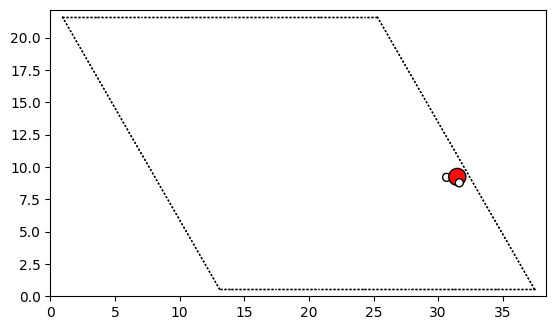

In [296]:
reconstructed_mol = Atoms(symbols=newmolec.labels, positions=newmolec.coord, cell=cell_parameters, pbc=True)
plot_atoms(reconstructed_mol)
view = nglview.show_ase(reconstructed_mol)
view.add_unitcell()
view

In [236]:
for ref in newcell.refmoleclist:
    if ref.formula == "H2-O":
        ref_labels_idx = [ref_labels[i] for i in ref.get_parent_indices("cell")]
        ref_frac_idx = [ref_fracs[i] for i in ref.get_parent_indices("cell")]
        print(ref.formula, ref.get_parent_indices("cell"), ref_frac_idx)

H2-O [12, 53, 56] [[0.96073, 0.41262, 0.9709], [0.9259, 0.411, 0.945], [0.9563, 0.3911, 1.044]]
H2-O [13, 54, 57] [[0.68302, 0.6317, 0.4667], [0.7016, 0.671, 0.435], [0.6549, 0.6439, 0.48]]
H2-O [14, 55, 58] [[0.91917, 0.32407, 0.2061], [0.8794, 0.316, 0.195], [0.917, 0.322, 0.297]]


In [227]:
finalnewmols

[]

In [228]:
finalremfrag

[]

In [196]:
remfrag

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Rec. Fragment
  Number of Atoms              = 41
  Formula                      = H22-C12-O7
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Rec. Fragment
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type           

In [191]:
newmols, remfrag = sequential(filtered_fragments, newcell.refmoleclist, cellvec=newcell.cellvec, typ="All", debug=2)

Entered sequential with 15 fragments to reconstruct
Found 15 and 0 Heavy and Hydrogen fragments, respectively


H22-C12-O7 ['O', 'O', 'O', 'O', 'O', 'O', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'C', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'O', 'H'] [[8.493205725000003, 8.195383526262713, 4.231314359999999], [9.099140910000001, 5.575722523726235, 4.9322930399999985], [8.580934125000002, 4.7520266490061935, 7.554505039999998], [6.5368624050000035, 6.06977121517374, 9.007249479999997], [5.766802005000002, 8.557531136055076, 8.150302799999997], [6.335208930000003, 9.487592043021824, 5.554410399999998], [9.010681440000003, 7.266166786218555, 3.2948239999999993], [9.51731295, 7.734679428257626, 2.6134387999999995], [8.280586200000002, 6.795543726873003, 2.8610379999999993], [9.885163005000003, 6.2989625346577185, 3.9927807999999994], [10.28249955, 5.687574640969796, 3.352337199999999], [10.599296550000002, 6.768108301888733, 4.450936799999999], [9.844832310000001, 4.557657215079174, 5.581704799999999], [10.598078100000002,

NGLWidget()

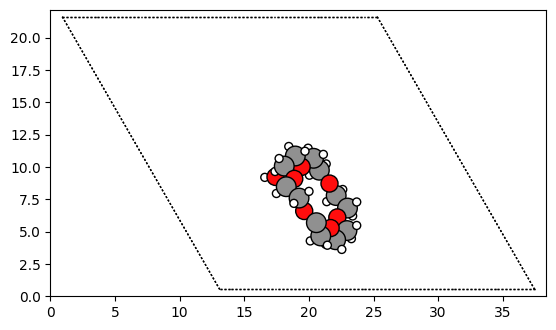

In [201]:
frag = remfrag[0]
print(frag.formula, frag.labels, frag.coord)
frag_mol = Atoms(symbols=frag.labels, positions=frag.coord, cell=cell_parameters, pbc=True)
plot_atoms(frag_mol)
view = nglview.show_ase(frag_mol)
view.add_unitcell()
view

In [176]:
updated_fraglist = []
updated_fraglist.extend(remfrag)
updated_fraglist.extend(hydrogens)

In [187]:
for mol in molecules:
    print(mol.formula)

H2-O
H2-O
K
K
K


In [188]:
2+4+4

10

In [189]:
hydrogens

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = H
  Number of Atoms              = 1
  Formula                      = H
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = H
  Number of Atoms              = 1
  Formula                      = H
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_moleclist
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1


In [185]:
for ref in remfrag:
    print(ref.formula)

H22-C12-O7
C6-O12-Fe
H20-C12-O6
H20-C12-O6


In [184]:
for ref in newcell.refmoleclist:
    print(ref.formula)

C6-O12-Fe
H24-C12-O6
H2-O
H2-O
H2-O
H24-C12-O6
H24-C12-O6
K
K
K


In [177]:
updated_fraglist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Rec. Fragment
  Number of Atoms              = 41
  Formula                      = H22-C12-O7
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Rec. Fragment
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type           

In [179]:
finalmols, final_remfrag = sequential(updated_fraglist, newcell.refmoleclist, cellvec=newcell.cellvec, typ="All", debug=2)

Entered sequential with 16 fragments to reconstruct
Found 4 and 12 Heavy and Hydrogen fragments, respectively
 
Fragments to allocate: 0 0 out of 3 11
sublist 2 ['H22-C12-O7', 'H']
list1 4 ['H22-C12-O7', 'C6-O12-Fe', 'H20-C12-O6', 'H20-C12-O6']
list2 12 ['H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
keeplist1 3 ['C6-O12-Fe', 'H20-C12-O6', 'H20-C12-O6']
keeplist2 11 ['H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']

SEQUENTIAL All iteration 1 with 4 and 12 Remaining in each list
SEQUENTIAL All sending ['O', 'O', 'O', 'O', 'O', 'O', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'C', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'O', 'H'] and ['H'] to combine
MERGE_FRAGMENTS: keep_idx 0
MERGE_FRAGMENTS: move_idx 1
MERGE_FRAGMENTS: move_frag.tmatrix [(0, 0, 0), (0, 0, -1), (0, 1, 0), (0, 1, -1)]
MERGE_FRAGMENTS: translation (0, 0, 0)
MERGE_FRAGMENTS: count_species found 2
MERGE_FRAGMENTS: translation (0

In [181]:
final_remfrag

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Heavy
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = Rec. Fragment
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                   